In [ ]:
from ase.io import read, write
from ase.visualize import view
from rdkit.Chem import Draw

import os, yaml, glob

from openmm.openmm import XmlSerializer
from openmm.app import PME
from openmm.app.forcefield import ForceField
from openmm.app.pdbfile import PDBFile

from imolcryff.asemol import asemol_wrapper, aseatoms2pdb, merge_asemols
from imolcryff.molinfo import Mol_Info
from imolcryff.g16wrapper import molinfo_setg16opt, molinfo_setg16charge, molinfo_setg16dihedral
from imolcryff.gaffil_generators import GAFFilTemplateGenerator
from imolcryff.ffxml import gafftemplate2xml

/Users/srak/Desktop/imc/imolcryff/DMFF/dmff/admp/qeq.py:33: UserWarning: jaxopt not found, QEQ cannot be used.
  warnings.warn("jaxopt not found, QEQ cannot be used.")


In [ ]:
import imolcryff
imolcryff.__file__

'/Users/srak/Desktop/imc/imolcryff/imolcryff/__init__.py'

In [ ]:
!pwd

/Users/srak/Desktop/imc/test/crystal


/Users/srak/miniconda3/envs/imolcry/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [ ]:
params = yaml.safe_load(open('all_params.yaml'))
params

{'g16opt': {'basis': '6-311++g(d,p)',
  'mem': '32GB',
  'method': 'wb97xd',
  'nprocshared': 32,
  'opt': 'maxcycle=256'},
 'charge': {'basis': '6-31g(d)',
  'algo': 'resp',
  'mem': '32GB',
  'method': 'hf',
  'nprocshared': 32},
 'ff_params': {'fftype': 'gaff-2.11',
  'iontype': 'amber/ions/ionsff99_tip3p.xml',
  'charge_scale_ion': 0.8,
  'charge_scale_neutral': 1.0},
 'fsa_assign': {'FSA': {'F': 'f', 'N': 'n', 'O': 'o', 'S': 's6'}}}

In [ ]:
atoms = read("ordered_Li(FSA)(C2)2_233K.cif")
asemol_wrap = asemol_wrapper(atoms)
atoms_unwrap = asemol_wrap.unwrap_molecules()
atomslist_mols, molecule_list = asemol_wrap.get_ase_molecules(ordered=True)

merged_aseatoms = merge_asemols(atomslist_mols)
aseatoms2pdb("merged.pdb", merged_aseatoms)

In [ ]:
import rdkit
rdkit.__version__

'2024.03.2'

In [ ]:
mol_info = Mol_Info()

In [ ]:
for i, mol_idx in enumerate(molecule_list):
    al = [atomslist_mols[i] for i in mol_idx]
    mol_info.append_fromAtomsList(al, key=f"MOL_{i}", Nmols = len(mol_idx))

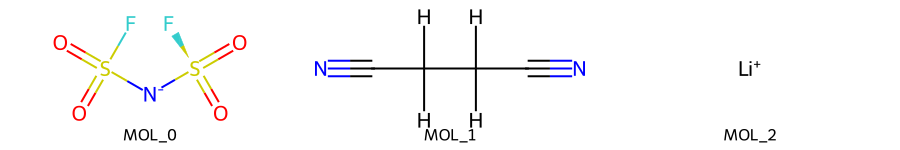

In [ ]:
mol_info.auto_charge_assign()
mol_info.get_rdkitmol()
mol_info.il_assign()
rdkitmol_list = [mol_info.mol_info[key]["rdkitmol2d"] for key in mol_info.mol_info.keys()]
Draw.MolsToGridImage(rdkitmol_list, molsPerRow = 3, subImgSize = (300,150),
                     legends = [molkey for molkey in mol_info.mol_info.keys()], maxMols = 60)

In [ ]:
default_params_dihedral = {
    "method": "wb97xd",
    "basis": "6-311++g(d,p)",
    "opt": "modredundant",
    "mem": "92GB",
    "nprocshared": 40,
    "addsec": "hoge-hoge"
}

In [ ]:
mol_info.get_smiles_from_molinfo()
mol_info.get_sdf_from_molinfo()
molinfo_setg16opt(mol_info.mol_info, params["g16opt"])
mol_info.do_geoopt()  # you need Gaussian16
mol_info.load_geoopt_results()

molinfo_setg16charge(mol_info.mol_info, params["charge"])
mol_info.do_charge()

# if you want to calculate dihedral potential energy profile
# mol_info.get_rotatable_dihedral()
# molinfo_setg16dihedral(mol_info.mol_info)
# mol_info.do_dihedral()   # you need Gaussian16
# mol_info.load_dihedral_results()

Skip MOL_0/MOL_0_0.log
Skip MOL_0/MOL_0_1.log
Skip MOL_0/MOL_0_2.log
Skip MOL_0/MOL_0_3.log
Skip MOL_1/MOL_1_0.log
Skip MOL_1/MOL_1_1.log
Skip MOL_1/MOL_1_2.log
Skip MOL_1/MOL_1_3.log
Skip MOL_1/MOL_1_4.log
Skip MOL_1/MOL_1_5.log
Skip MOL_1/MOL_1_6.log
Skip MOL_1/MOL_1_7.log
Skip MOL_2/MOL_2_0.log
Skip MOL_2/MOL_2_1.log
Skip MOL_2/MOL_2_2.log
Skip MOL_2/MOL_2_3.log
Skip MOL_0/MOL_0_charge.log
Skip MOL_1/MOL_1_charge.log
Skip MOL_2/MOL_2_charge.log


In [ ]:
for i in range(10):
    try:
        _ = mol_info.get_charges_from_molinfo()
    except:
        pass

dict_keys(['MOL_0', 'MOL_1', 'MOL_2'])
MOL_0
antechamber -i /Users/srak/Desktop/imc/test/crystal/MOL_0/MOL_0_charge.log -fi gout -o MOL_0/resp_charge.mol2 -fo mol2 -at sybyl -c resp -nc -1 -pf y -dr no

Welcome to antechamber 22.0: molecular input file processor.

Info: The atom type is set to sybyl; the options available to the -at flag are
      gaff, gaff2, amber, bcc, and sybyl.

Info: Bond types are assigned for valence state (1) with penalty (1).



dyld[88190]: dyld cache '(null)' not loaded: syscall to map cache into shared region failed
dyld[88190]: Library not loaded: /usr/lib/libSystem.B.dylib
  Referenced from: <AF7A006F-BB73-3DA5-A5D6-09005315D0EE> /Users/srak/miniconda3/envs/imolcry/bin/resp
  Reason: tried: '/usr/lib/libSystem.B.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/usr/lib/libSystem.B.dylib' (no such file), '/usr/lib/libSystem.B.dylib' (no such file, no dyld cache), '/usr/local/lib/libSystem.B.dylib' (no such file)
/Users/srak/miniconda3/envs/imol

In [ ]:
mol_info.adjust_charges(params["ff_params"]) # necesarry even for neutral species

1.600000000046009e-06
Net charge of MOL_0 is -0.8 and total charge is -0.7999984
1.9999999999742446e-06
Net charge of MOL_1 is 0 and total charge is 1.9999999999742446e-06
0.0


In [ ]:
mol_info.save_molinfo("molinfo.pkl")

In [ ]:
# Generate a supercell
atomspdb = read("merged.pdb") 
atomspdb = atomspdb.repeat((1,1,1))
aseatoms2pdb("merged_supercell.pdb", atomspdb)


In [ ]:
# fixed pdb format

# delete redundant space between resides name and their indeces
input_pdb = "merged_supercell.pdb"
output_pdb = "fixed_merged_supercell.pdb"

with open(input_pdb, "r") as infile, open(output_pdb, "w") as outfile:
    for line in infile:
        if line.startswith(("ATOM", "HETATM")):  # 原子データ行のみ処理
            line = line[:19] + line[21:]  # 20-21列をカット
        outfile.write(line)

print(f"修正完了: {output_pdb}")


In [ ]:
# Gerate bonds of the supercell
from tqdm import tqdm
from openmm.app import PDBFile
from ase.io import read
from imolcryff.asemol import asemol_wrapper

pdb_file_name = "fixed_merged_supercell"
pdb = PDBFile(pdb_file_name + ".pdb")  # PDBファイルを読み込む
atomspdb = read(pdb_file_name + ".pdb")  # ASEで読み込む

# asemol_wrapper でボンド情報を取得
pdb_b = asemol_wrapper(atomspdb)
_ = pdb_b.get_bonds()
bonds_list = [[bond[0], bond[1]] for bond in pdb_b.bonds]
atomlist_openmm = list(pdb.topology.atoms())

# 進捗バーを使ってボンド追加
print("Adding bonds to topology...")
for bond in tqdm(bonds_list, desc="Processing Bonds", unit="bond"):
    a1 = atomlist_openmm[bond[0]]
    a2 = atomlist_openmm[bond[1]]
    pdb.topology.addBond(a1, a2)

# PDBファイルを書き出し
output_pdb = pdb_file_name + "_bonds.pdb_test"
print(f"Writing modified PDB file to {output_pdb}...")
with open(output_pdb, "w") as f:
    pdb.writeFile(pdb.topology, pdb.positions, f)

print("Processing complete!")

pdb = PDBFile("fixed_merged_supercell_bonds.pdb")

In [ ]:
# fixed pdb format

input_file = "fixed_merged_supercell_bonds.pdb"
output_file = "fixed_merged_supercell_bonds_edit.pdb"

with open(input_file, "r") as infile, open(output_file, "w") as outfile:
    for line in infile:
        modified_line = line.replace("I", "LI")  # "I" を "LI" に置換
        outfile.write(modified_line)

print(f"Processed file saved as {output_file}")


In [ ]:
pdb = PDBFile("fixed_merged_supercell_bonds_edit.pdb")
mmm = mol_info.get_molecule_omm()
if params["ff_params"]["fftype"].split("-")[0] == "gaff":
    gaff = GAFFilTemplateGenerator(molecules=mmm, forcefield=params["ff_params"]["fftype"], il_assign=params["fsa_assign"])

gafftemplate2xml(mmm, gaff, ion_ffxml=params["ff_params"]["iontype"])

In [17]:
gaff_files = sorted(glob.glob("gaffxml_*.xml"))
forcefield = ForceField(*gaff_files)
sys = forcefield.createSystem(pdb.topology, nonbondedMethod=PME)
with open('system.xml', 'w') as output:
    output.write(XmlSerializer.serialize(sys))

In [18]:
from openmm import app
from parmed.openmm import load_topology

parm_top = load_topology(topology=pdb.topology, system=sys, xyz=pdb.positions)

parm_top.save('test.top', overwrite=True)
parm_top.save('test.gro', overwrite=True)

In [19]:
from openff.interchange.components.mdconfig import MDConfig
from openff.toolkit import Topology
from openff.interchange.interop import openmm
from openff.interchange.interop.lammps.export import to_lammps
from imolcryff.exporter_lmp import to_lammps_non_rectangular

topology_off = Topology.from_openmm(pdb.topology, unique_molecules=mmm)
os.environ["INTERCHANGE_EXPERIMENTAL"] = "1"
a = openmm.from_openmm(system=sys, topology=topology_off, positions=pdb.getPositions())
to_lammps(a, "test.data")
# non-rectangular box
# to_lammps_non_rectangular(a, "test.data")